In [1]:
# Imports 

import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, norm
from matplotlib import pyplot as plt
import time

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Directories and Global Variables
DATA_DIRECTORY = "./results"

# Retreive all Directories and files in the results 
QUALITY_DIRECTORIES = os.listdir(DATA_DIRECTORY)

In [3]:
files = []
for q in QUALITY_DIRECTORIES: 
    runs = os.listdir(f"{DATA_DIRECTORY}/{q}")
    for f in runs: 
        files.append(f"{q}/{f}")
files

['all-off/run_11.csv',
 'all-off/run_10.csv',
 'all-off/run_04.csv',
 'ambient-mode/run_06.csv',
 'ambient-mode/run_07.csv',
 'ambient-mode/run_02.csv',
 'stable-volume/run_03.csv',
 'stable-volume/run_09.csv',
 'stable-volume/run_08.csv',
 'voice-boost/run_12.csv',
 'voice-boost/run_05.csv',
 'voice-boost/run_01.csv']

In [4]:
example = pd.read_csv(f"{DATA_DIRECTORY}/{files[0]}")[['Time', 'SYSTEM_POWER (Watts)']]
first_time = example['Time'].iloc[0]
example['Time'] = example['Time'].apply(lambda x: (x - first_time) / 1000)
example.head(10)

,Time,SYSTEM_POWER (Watts)
0,0.000,11.038245
1,0.000,11.038245
2,0.205,11.038245
3,0.407,11.038245
4,0.608,11.038245
5,0.809,11.462996
6,1.010,11.462996
7,1.212,11.462996
8,1.416,11.462996
9,1.618,11.462996


In [5]:
# Check whether Data is normal

stats, p_val = shapiro(example['SYSTEM_POWER (Watts)'])

print(f"With p-val {p_val}, the data is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}")

With p-val 1.7774321060639834e-08, the data is NOT NORMAL


In [6]:
# Normalising the data

mean = example['SYSTEM_POWER (Watts)'].mean()
std = example['SYSTEM_POWER (Watts)'].std()
outlier = []
max_diff = 0
print(f"std: {3 * std}")
for idx, val in enumerate(example['SYSTEM_POWER (Watts)']): 
    diff = mean - val
    if np.abs(diff) > max_diff: max_diff = np.abs(diff) 
    if np.abs(diff) > 3*std: 
        print(f"Found outlier at {idx}")
        outlier.append(idx)

print(max_diff)
normalised_example = example.drop(index=outlier) 
normalised_example   


std: 1.0218016281705102
0.9226790555318196


,Time,SYSTEM_POWER (Watts)
0,0.000,11.038245
1,0.000,11.038245
2,0.205,11.038245
3,0.407,11.038245
4,0.608,11.038245
...,...,...
145,29.251,11.029516
146,29.452,11.029516
147,29.655,11.029516
148,29.860,10.603209


Text(0, 0.5, 'System Power measurement (Watts)')

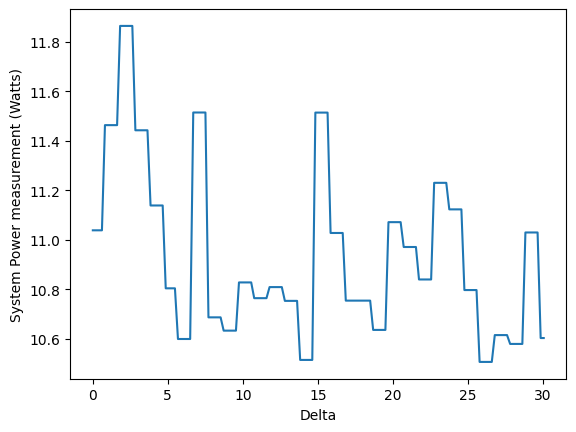

In [7]:
#Plotting data distribution
plt.plot(example['Time'], example['SYSTEM_POWER (Watts)'])
plt.xlabel("Delta")
plt.ylabel("System Power measurement (Watts)")

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7fe7c66e1910>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fe7c66e7740>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fe7c66fc860>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fe7c66fcf20>}

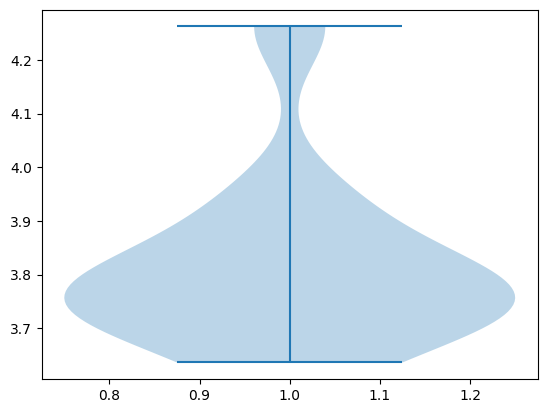

In [12]:
# Violin plots

plt.violinplot(example['SYSTEM_POWER (Watts)'])


### Creating a general setup to create combinations by subcategories 

The outlier removal didn't work, possibly becasue there are not enough sample. Might have to do something else. 

In [8]:
dataframes = {}
for f in files: 
    print(f"======== Converting file '{f}' ========")
    df = pd.read_csv(f"{DATA_DIRECTORY}/{f}")[['Time', 'SYSTEM_POWER (Watts)']]
    first_time = df['Time'].iloc[0]
    df['Time'] = df['Time'].apply(lambda x: (x - first_time) / 1000)
    dataframes[f] = df
    
dataframes[f]

======== Converting file 'all-off/run_11.csv' ========
======== Converting file 'all-off/run_10.csv' ========
======== Converting file 'all-off/run_04.csv' ========
======== Converting file 'ambient-mode/run_06.csv' ========
======== Converting file 'ambient-mode/run_07.csv' ========
======== Converting file 'ambient-mode/run_02.csv' ========
======== Converting file 'stable-volume/run_03.csv' ========
======== Converting file 'stable-volume/run_09.csv' ========
======== Converting file 'stable-volume/run_08.csv' ========
======== Converting file 'voice-boost/run_12.csv' ========
======== Converting file 'voice-boost/run_05.csv' ========
======== Converting file 'voice-boost/run_01.csv' ========


,Time,SYSTEM_POWER (Watts)
0,0.000,12.197943
1,0.000,12.197943
2,0.205,12.197943
3,0.406,12.197943
4,0.613,14.354152
...,...,...
145,29.276,10.839881
146,29.478,10.839881
147,29.683,10.733613
148,29.886,10.733613


In [9]:
for f, df in dataframes.items():
    stats, p_val = shapiro(df['SYSTEM_POWER (Watts)'])

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 1.7774321060639834e-08, the data in all-off/run_11.csv is NOT NORMAL
With p-val 1.6019826569002537e-19, the data in all-off/run_10.csv is NOT NORMAL
With p-val 1.2189041344011187e-15, the data in all-off/run_04.csv is NOT NORMAL
With p-val 2.6820712277659094e-11, the data in ambient-mode/run_06.csv is NOT NORMAL
With p-val 1.0290859398129043e-13, the data in ambient-mode/run_07.csv is NOT NORMAL
With p-val 4.282285500538731e-11, the data in ambient-mode/run_02.csv is NOT NORMAL
With p-val 3.604101155127548e-18, the data in stable-volume/run_03.csv is NOT NORMAL
With p-val 1.0591789607844513e-09, the data in stable-volume/run_09.csv is NOT NORMAL
With p-val 6.941123473049876e-16, the data in stable-volume/run_08.csv is NOT NORMAL
With p-val 2.810307702037978e-16, the data in voice-boost/run_12.csv is NOT NORMAL
With p-val 5.385818868968519e-18, the data in voice-boost/run_05.csv is NOT NORMAL
With p-val 1.0207612860152972e-16, the data in voice-boost/run_01.csv is NOT NORMAL


In [10]:
normalised_dataframes = {}
for f, df in dataframes.items(): 
    mean = df['SYSTEM_POWER (Watts)'].mean()
    std = df['SYSTEM_POWER (Watts)'].std()
    outlier = []
    max_diff = 0
    print(f"3x std: {3 * std} | mean: {mean}")
    for idx, val in enumerate(df['SYSTEM_POWER (Watts)']): 
        diff = mean - val
        abs = np.abs(diff)
        if abs > max_diff: max_diff = abs
        if abs > 3*std: 
            print(f"Found outlier at {idx}")
            outlier.append(idx)

    print(f"Maximum difference found: {max_diff}")
    n_df = df.drop(index=outlier) 
    normalised_dataframes[f] = n_df
    print("===============================================")

3x std: 1.0218016281705102 | mean: 10.940987478892009
Maximum difference found: 0.9226790555318196
3x std: 2.8329834312340596 | mean: 10.918558298746746
Found outlier at 93
Found outlier at 94
Found outlier at 95
Found outlier at 96
Found outlier at 97
Maximum difference found: 4.573292554219563
3x std: 4.612617044175082 | mean: 11.751408983866373
Found outlier at 49
Found outlier at 50
Found outlier at 51
Found outlier at 52
Found outlier at 53
Found outlier at 54
Found outlier at 55
Found outlier at 56
Found outlier at 57
Found outlier at 58
Maximum difference found: 5.071217130025229
3x std: 12.158187994623727 | mean: 16.970218978472204
Maximum difference found: 6.780991874285192
3x std: 13.40796372956505 | mean: 16.213756164448373
Maximum difference found: 5.907202163798697
3x std: 13.008355141683017 | mean: 17.3018793707726
Maximum difference found: 6.94444414433217
3x std: 3.2149051994514757 | mean: 11.030490970611572
Found outlier at 26
Found outlier at 27
Found outlier at 28
Fo

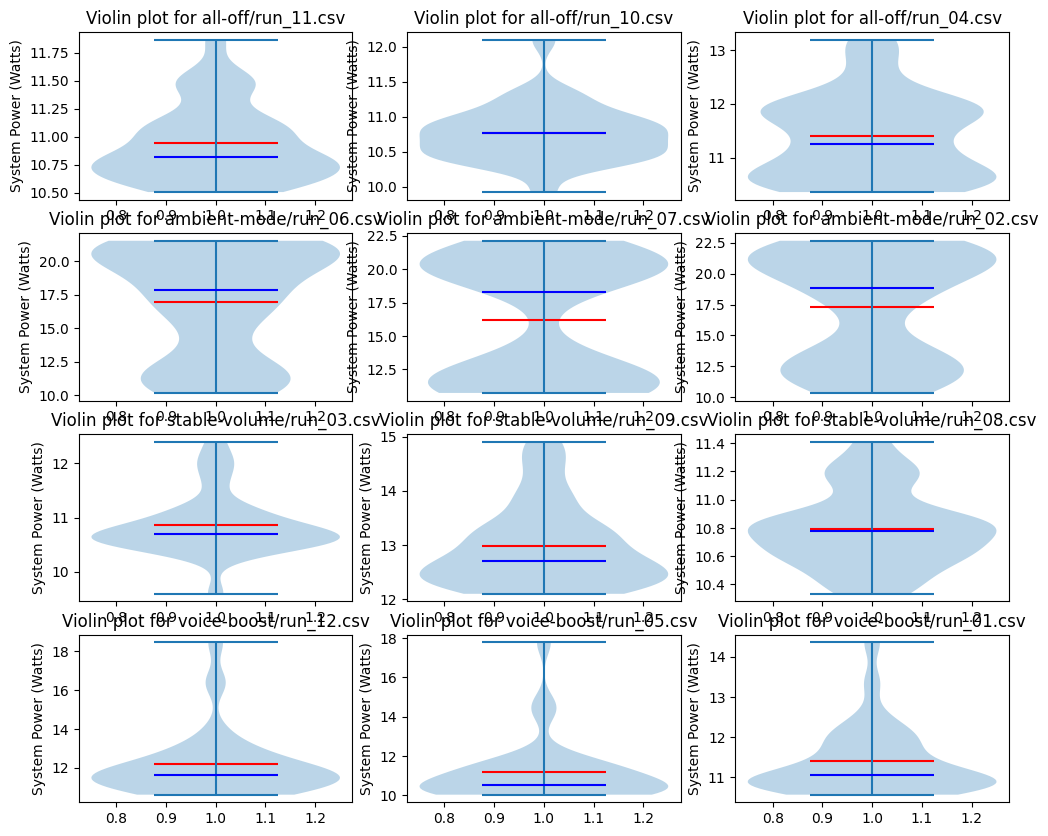

In [11]:
fig, plots = plt.subplots(nrows = len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")),
                               figsize =(12, 10))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(df['SYSTEM_POWER (Watts)'], showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.show()

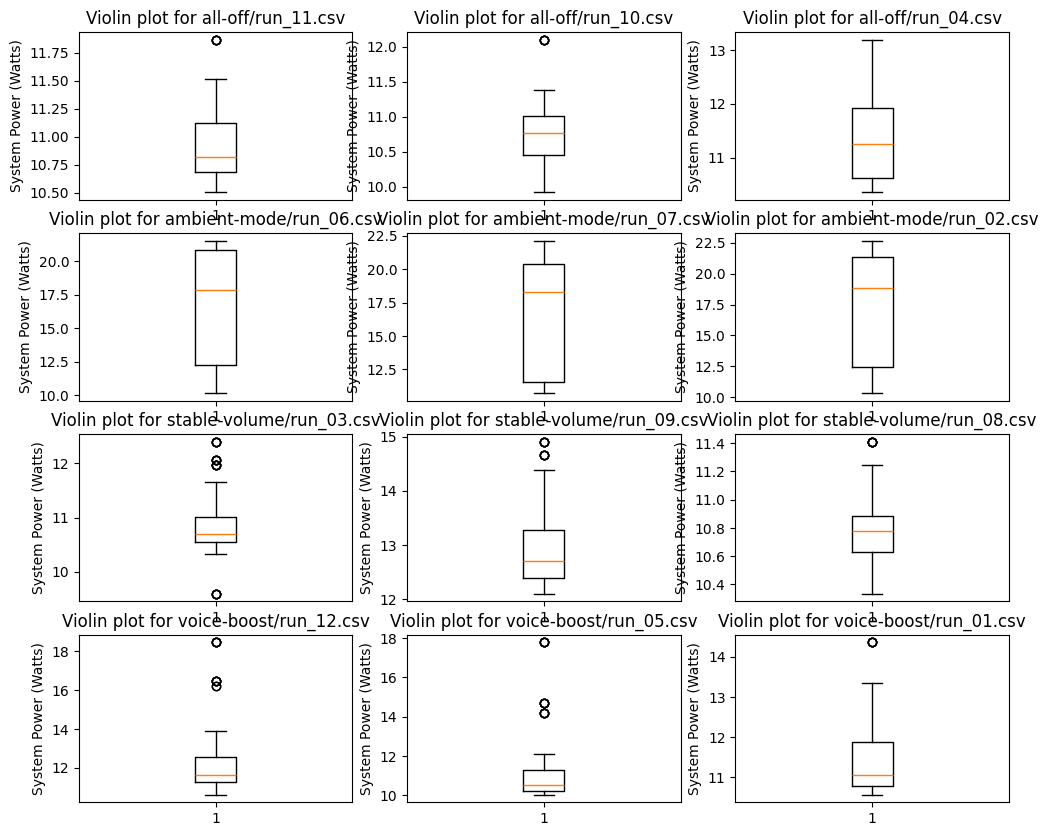

In [12]:
fig, plots = plt.subplots(nrows = len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")),
                               figsize =(12, 10))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(df['SYSTEM_POWER (Watts)'])

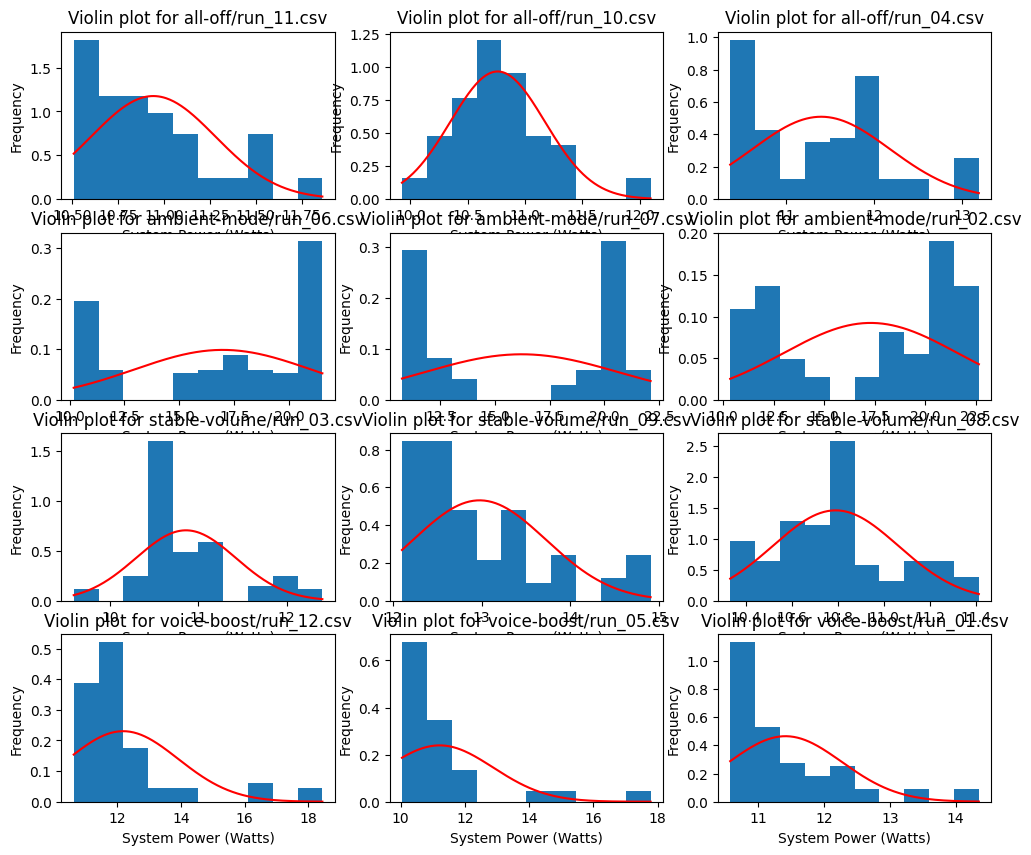

In [13]:
fig, plots = plt.subplots(nrows = len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")),
                               figsize =(12, 10))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(df['SYSTEM_POWER (Watts)'], density=True)
    mu, std = norm.fit(df['SYSTEM_POWER (Watts)'])
    x = np.linspace(df['SYSTEM_POWER (Watts)'].min(), df['SYSTEM_POWER (Watts)'].max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')